In [4]:
!pip install whitebox rasterio
!pip install contextily


import contextily as cx
from google.colab import drive
import os
from whitebox import WhiteboxTools
import rasterio
import numpy as np
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Landslide_CNN_Project'
RAW_DATA = os.path.join(BASE_PATH,'01_Raw_Data')
WBT_DIR = os.path.join(BASE_PATH, '02_WBT_Intermediate')
os.makedirs(WBT_DIR, exist_ok=True)

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                  

KeyboardInterrupt: 

In [5]:
# Read the dem from google drive

dem_path = os.path.join(RAW_DATA, 'DEM', 'smoothed_raster.tif')

with rasterio.open(dem_path) as src:
    dem = src.read()


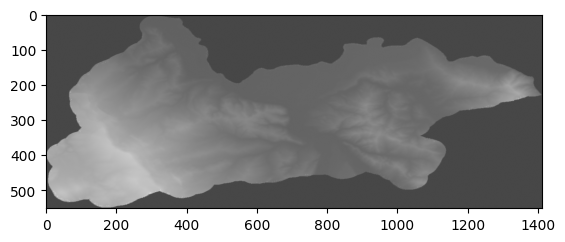

In [6]:
#Visualize the raster


import matplotlib.pyplot as plt
plt.imshow(dem[0], cmap='gray')


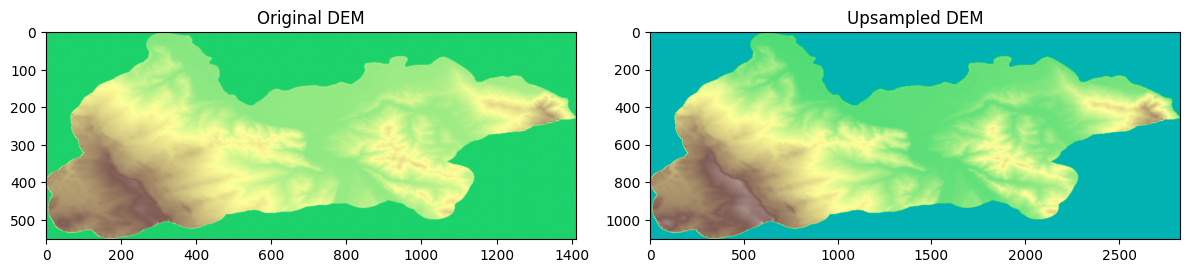

In [7]:
#Upsampling the raster

from rasterio.enums import Resampling
import matplotlib.pyplot as plt

upscale_factor = 2

with rasterio.open(dem_path) as dataset:
  data = dataset.read(
      out_shape=(
          dataset.count,
          int(dataset.height * upscale_factor),
          int(dataset.width * upscale_factor)
      ),
      resampling=Resampling.bilinear
      )

  transform = dataset.transform * dataset.transform.scale(
      (dataset.width / data.shape[-1]),
      (dataset.height / data.shape[-2])
  )

upsampled_dem_path = os.path.join(RAW_DATA, 'DEM', 'upsampled_raster.tif')

with rasterio.open(
    upsampled_dem_path,
    'w',
    driver='GTiff',
    height=data.shape[1],
    width=data.shape[2],
    count=dataset.count,
    dtype=data.dtype,
    crs=dataset.crs,
    transform=transform,
    ) as dst:
      dst.write(data)

with rasterio.open(dem_path) as src:
    original_data = src.read()

with rasterio.open(upsampled_dem_path) as src:
    upsampled_data = src.read()

# Create a single figure with two subplots

fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].set_title('Original DEM')
ax[0].imshow(original_data[0], cmap='terrain')
ax[1].set_title('Upsampled DEM')
ax[1].imshow(upsampled_data[0], cmap='terrain')
plt.tight_layout()
plt.show()

In [ ]:
from rasterio.warp import calculate_default_transform, reproject, Resampling
import os
import rasterio

def reproject_raster(input_path, output_path, target_crs='EPSG:32624'):
    """Reprojects a raster to a target CRS (Coordinate Reference System).

    Args:
        input_path (str): Path to the input raster.
        output_path (str): Path where the reprojected raster will be saved.
        target_crs (str): The EPSG code of the target projection.
    """
    with rasterio.open(input_path) as src:
        # 1. Calculate the new transform and dimensions for the target CRS
        transform, width, height = calculate_default_transform(
            src.crs,
            target_crs,
            src.width,
            src.height,
            *src.bounds
        )

        # 2. Copy and update metadata for the new file
        metadata = src.meta.copy()
        metadata.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height,
            'nodata': -9999  # Standardized nodata value
        })

        # 3. Perform the actual reprojection
        with rasterio.open(output_path, 'w', **metadata) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    # Fallback for nodata handling
                    src_nodata=src.nodata if src.nodata is not None else 0,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    dst_nodata=-9999,
                    resampling=Resampling.nearest
                )

    print(f"Reprojection complete: {output_path}")
    return output_path


reprojected_path = os.path.join(WBT_DIR, 'reprojected_raster.tif')
reproject_raster(upsampled_dem_path, reprojected_path, target_crs='EPSG:32624')

In [ ]:
#Use Whiteboxtools to fill the depression of the area

wbt = WhiteboxTools()


with rasterio.open(reprojected_path) as src_in:
    print(f"Input Min: {src_in.read().min()}, Max: {src_in.read().max()}")

with rasterio.open(reprojected_path) as src_out:
    data = src_out.read(1)
    print(f"Output Min: {data.min()}, Max: {data.max()}")
    print(f"Number of non-zero pixels: {np.count_nonzero(data)}")

wbt.working_directory = WBT_DIR

wbt.fill_depressions(
    dem = reprojected_path,
    output= os.path.join(WBT_DIR, 'fill_depressions.tif'),
    fix_flats=True)


In [ ]:
output_path = os.path.join(WBT_DIR, 'fill_depressions.tif')


with rasterio.open(output_path) as src:
  dem_data = src.read(1, masked=True)
  extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]





In [ ]:
plt.clf()
plt.figure(figsize=(10,8))

dem_data = np.ma.masked_outside(dem_data, 1, 10000)

current_cmap = plt.cm.get_cmap('terrain').copy()
current_cmap.set_bad('white', alpha=0)

img = plt.imshow(dem_data,
                 cmap=current_cmap,
                 extent=extent,
                 vmin=np.ma.min(dem_data),
                 vmax=np.ma.max(dem_data))

plt.colorbar(img, label='Elevation (m)')
plt.title('Fill Depressions (Transparent Background)')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.show()

In [ ]:

with rasterio.open(output_path) as src:
  dem_data = src.read(1, masked=True).astype('float32')

# Make the background of the plot as a satellite image

fig, ax = plt.subplots(figsize=(12,10))

img = ax.imshow(dem_data, cmap='terrain', extent=[
    src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top],
                alpha=0.6,
                zorder=1)

cx.add_basemap(ax, crs=src.crs.to_string(), source=cx.providers.Esri.WorldImagery)


plt.colorbar(img, label='Elevation (m)', ax=ax, shrink=0.6)
plt.title('DEM Overlaid on Satellite Imagery')
plt.show()


In [ ]:
# Calculate the slope of the dem
wbt.slope(dem=reprojected_path,
          output=os.path.join(WBT_DIR, 'slope.tif'),
          units='degrees')

slope_filepath = os.path.join(WBT_DIR, 'slope.tif')
with rasterio.open(slope_filepath) as src_slope:
  slope_data = src_slope.read(1, masked=True)
  slope_crs = src_slope.crs




In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Define degrees for slope

bounds = [0, 10, 20, 30, 45, 90]

# Chose the color ramp for slope

color_list = ['#E0E0E0','#F5F5DC','#FFE082', '#FB8C00', '#E53935', '#B71C1C', '#4A0000']
cmap_discrete = plt.matplotlib.colors.ListedColormap(color_list)
norm = colors.BoundaryNorm(bounds, cmap_discrete.N)

#Visualize the Slope

fig, ax = plt.subplots(figsize=(12,10))


with rasterio.open(slope_filepath) as src_slope:
  slope_extent = [src_slope.bounds.left, src_slope.bounds.right, src_slope.bounds.bottom, src_slope.bounds.top]
  slope_crs = src_slope.crs


img = ax.imshow(slope_data,
                cmap=cmap_discrete,
                norm=norm,
                extent=slope_extent,
                alpha=0.6,
                zorder=1)

cx.add_basemap(ax, crs=slope_crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)

# Create the legend

cbar = plt.colorbar(img, ax=ax, boundaries=bounds, ticks=bounds[1:], shrink=0.6)
cbar.set_label('Slope Class (Degrees)', rotation=270, labelpad=15)
cbar.ax.set_yticklabels(['10', '20', '30', '45', '90'])
plt.title('Classified Slope')
plt.show()

In [ ]:
#Find the aspect

wbt.aspect(dem=reprojected_path,
           output=os.path.join(WBT_DIR, 'aspect.tif'),
           zfactor=1.0)


In [ ]:
input_path = reprojected_path
output_sin_path = os.path.join(WBT_DIR, 'aspect_sin.tif')
output_cos_path = os.path.join(WBT_DIR, 'aspect_cos.tif')

def process_aspect_to_trig(input_path, output_sin_path, output_cos_path):
  with rasterio.open(input_path) as src:
    aspect_deg = src.read(1).astype('float32')
    profile = src.profile

    # Mask out NoData or Flat areas
    nodata_val = src.nodata if src.nodata is not None else -9999 # Define nodata_val
    mask = (aspect_deg < 0) | (aspect_deg > 360) | (aspect_deg == nodata_val)
    clean_aspect = np.where(mask, 0, aspect_deg)

    #Convert degrees to radians

    aspect_rad = np.radians(aspect_deg)

    #Calculate sin and cos

    sin_aspect = np.sin(aspect_rad)
    cos_aspect = np.cos(aspect_rad)

    #Re-apply mask so NoData remains NoData

    sin_aspect[mask] = nodata_val
    cos_aspect[mask] = nodata_val

    #Update the profile for output files

    profile.update(nodata=nodata_val)

    with rasterio.open(output_sin_path, 'w', **profile) as dst:
      dst.write(sin_aspect, 1)

    with rasterio.open(output_cos_path, 'w', **profile) as dst:
        dst.write(cos_aspect, 1)

  print(f'Succesfully processed {input_path} to {output_sin_path} and {output_cos_path}')

process_aspect_to_trig(input_path, output_sin_path, output_cos_path)


# Verification step

with rasterio.open(output_sin_path) as test_src:
  valid_data = test_src.read(1)
  valid_data = valid_data[valid_data != test_src.nodata]
  print(f'Sine Range: {valid_data.min()} to {valid_data.max()}')


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
filled_dem = os.path.join(WBT_DIR, 'fill_depressions.tif')

wbt.d_inf_flow_accumulation(
    i=filled_dem,
    output=os.path.join(WBT_DIR, 'flow_accum.tif')
)

#Validation step and visualization
flow_accum_path = os.path.join(WBT_DIR, 'flow_accum.tif')

In [ ]:
with rasterio.open(flow_accum_path) as src:
  flow_accum_data = src.read(1, masked=True)
  flow_accum_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Create a figure and an axes object for plotting

plt.figure(figsize=(12,10))
plt.imshow(flow_accum_data, cmap='viridis', norm=LogNorm(1, flow_accum_data.max()))
plt.colorbar(label='Log of Upstream Cells')
plt.title('Flow Accumulation (Log Scaled)')
plt.show()



In [ ]:
'''Apply logarithmic transformation for the CNN to understand the flow acumulation'''

def log_transform_flow(input_path, output_path):
  with rasterio.open(input_path) as src:
    data=src.read(1).astype('float32')

    data_logged = np.where(data >= 0, np.log10(data + 1), -9999)

    meta = src.meta.copy()
    meta.update(dtype='float32', nodata=-9999)

    with rasterio.open(output_path, 'w', **meta) as dst:
      dst.write(data_logged, 1)

  print(f'Log transformation saved to:{output_path}')
  return output_path


flow_accum_path = os.path.join(WBT_DIR, 'flow_accum.tif')
log_flow_path = os.path.join(WBT_DIR, 'log_flow_accum.tif')
log_transform_flow(flow_accum_path, log_flow_path)


In [ ]:
'''Calculate the Topographic Indices'''

wbt.ruggedness_index(
    dem=os.path.join(WBT_DIR, 'fill_depressions.tif'),
    output=os.path.join(WBT_DIR, 'Ruggedness.tif')
)

wbt.wetness_index(
    sca=os.path.join(WBT_DIR, 'flow_accum.tif'),
    slope=os.path.join(WBT_DIR, 'slope.tif'),
    output=os.path.join(WBT_DIR, 'TWI.tif')
)

In [ ]:
def plot_topographic_check(twi_path, rugged_path):
  with rasterio.open(twi_path) as src_twi, rasterio.open(rugged_path) as src_rugged:
    twi=src_twi.read(1, masked=True)
    rugged=src_rugged.read(1, masked=True)

    fig, ax = plt.subplots(1, 2, figsize=(12,6))


    # Plot Wetness Index
    im1=ax[0].imshow(twi, cmap='YlGnBu')
    ax[0].set_title('Topographic Wetness Index (TWI)')
    fig.colorbar(im1, ax=ax[0], label='Wetness Score')

    #Plot Ruggedness Index
    im2=ax[1].imshow(rugged, cmap='OrRd')
    ax[1].set_title('Topographic Ruggedness Index (TRI)')
    fig.colorbar(im2, ax=ax[1], label='Ruggedness Score')
    v_max = np.percentile(rugged.compressed(), 98)


    # Percentile clip for ruggedness
    v_max = np.percentile(rugged.compressed(), 98)
    plt.imshow(rugged, cmap='OrRd', vmax=v_max)


twi_file = os.path.join(WBT_DIR, 'TWI.tif')
rugged_file = os.path.join(WBT_DIR, 'Ruggedness.tif')

if os.path.exists(twi_file) and os.path.exists(rugged_file):
    plot_topographic_check(twi_file, rugged_file)
else:
    print("One of the files is missing! Check your WBT output names.")


In [ ]:
""" Calculate curvature (Plan and Profile)"""
wbt.plan_curvature(
    dem=os.path.join(WBT_DIR, 'fill_depressions.tif'),
    output=os.path.join(WBT_DIR, 'plan_curv.tif')
)

wbt.profile_curvature(
    dem=os.path.join(WBT_DIR, 'fill_depressions.tif'),
    output=os.path.join(WBT_DIR, 'profile_curv.tif')
)


#Plotting Curvature

def plot_curvature_check(plan_path, profile_path):
  with rasterio.open(plan_path) as src_plan, rasterio.open(profile_path) as src_profile:
    plan=src_plan.read(1, masked=True)
    profile=src_profile.read(1, masked=True)


    fig, ax = plt.subplots(1, 2, figsize=(12,6))


    #Plot Plan Curvature
    im1=ax[0].imshow(plan, cmap='coolwarm')
    ax[0].set_title('Plan Curvature (Horizontal)')
    fig.colorbar(im1, ax=ax[0], label='Curvature Value')

    v_max = np.percentile(plan.compressed(), 98)
    plt.imshow(plan, cmap='coolwarm', vmax=v_max)


    #Plot Profile Curvature
    im2=ax[1].imshow(profile, cmap='coolwarm')
    ax[1].set_title('Profile Curvature (Vertical)')
    fig.colorbar(im2, ax=ax[1], label='Curvature Value')

    v_max = np.percentile(profile.compressed(), 98)
    plt.imshow(profile, cmap='coolwarm', vmax=v_max)


plan_path = os.path.join(WBT_DIR, 'plan_curv.tif')
profile_path = os.path.join(WBT_DIR, 'profile_curv.tif')

if os.path.exists(profile_path) and os.path.exists(plan_path):
    plot_curvature_check(profile_path, plan_path)


In [ ]:
"""Normalize and stack the data for CNN"""

def normalize_and_stack(file_list):
  stack = []

  for file_path in file_list:
    with rasterio.open(file_path) as src:
      data = src.read(1).astype('float32')

    #NoData Handling
    data[data == -9999] = np.nan

    #Z-score Normalization
    mu = np.nanmean(data)
    sigma = np.nanstd(data)
    normalized = (data - mu) / (sigma + 1e-8)

    normalized = np.nan_to_num(normalized)
    stack.append(normalized)

  return np.stack(stack)

layers = [
    os.path.join(WBT_DIR, 'aspect_cos.tif'),
    os.path.join(WBT_DIR, 'aspect_sin.tif'),
    os.path.join(WBT_DIR, 'slope.tif'),
    os.path.join(WBT_DIR, 'log_flow_accum.tif'),
    os.path.join(WBT_DIR, 'Ruggedness.tif'),
    os.path.join(WBT_DIR, 'TWI.tif'),
    os.path.join(WBT_DIR, 'plan_curv.tif'),
    os.path.join(WBT_DIR, 'profile_curv.tif')
]

final_stack = normalize_and_stack(layers)

In [ ]:
#Verify the layers

print(f"Final Stack Shape: {final_stack.shape}")
print(f"Stack Mean: {np.mean(final_stack):.4f}")
print(f"Stack Std: {np.std(final_stack):.4f}")

In [ ]:
#Check the slope layer
slope_layer = final_stack[2]
print(f"Slope Mean: {np.mean(slope_layer):.4f}")
print(f"Slope Std: {np.std(slope_layer):.4f}")

In [ ]:
#Save the stack
np.save(os.path.join(WBT_DIR, 'landslide_stack_v1.npy'), final_stack)